In [1]:
# using Pkg; Pkg.add("Contour")
# Pkg.add(["Images", "ImageIO", "FileIO", "ImageTransformations"])
# Pkg.add("CoordinateTransformations")
ENV["PYTHON"] = "/home/arun/miniconda3/envs/py311/bin/python" 
import Pkg
Pkg.build("PyCall")

    Building Conda ─→ `~/.julia/scratchspaces/44cfe95a-1eb2-52ea-b672-e2afdf69b78f/8f06b0cfa4c514c7b9546756dbae91fcfbc92dc9/build.log`
    Building PyCall → `~/.julia/scratchspaces/44cfe95a-1eb2-52ea-b672-e2afdf69b78f/9816a3826b0ebf49ab4926e2b18842ad8b5c8f04/build.log`


In [2]:
using CairoMakie
using DifferentialEquations
using SymPy
using LinearAlgebra
# using Contour


In [3]:
Axis = CairoMakie.Axis

Makie.Axis

In [4]:
function prey_predator!(du, u, param, t)
    x,y  = u
    alpha, beta, gamma, delta = param
    du[1] = alpha*x - beta*x*y
    du[2] = delta*x*y - gamma * y
end

prey_predator! (generic function with 1 method)

## Nullclines

In [5]:
function elem_of_f(f!, elem, u, param, t)
    du = zeros(length(u))
    f!(du, u, param, t)
    return du[elem]
end

elem_of_f (generic function with 1 method)

In [6]:
function draw_nullcline!(ax, f!, xory, param, color, linewidth)
    
    time_now = 0.0
    
    xs = LinRange(-5,10.0,100)
    ys = LinRange(-5,10.0,100)
    
    t = 0
    dxs = [elem_of_f(f!, xory, [x,y], param, t) for x in xs, y in ys]
    contour!(ax, xs, ys, dxs, levels=[0.0], color=color, linewidth=linewidth)
end

draw_nullcline! (generic function with 1 method)

In [7]:
function draw_arrows_on_nullcline!(ax, f!, xory, param, color, linewidth, lengthscale)

    alpha, beta, gamma, delta = param
    
    xs = LinRange(-5,10.0,100)
    ys = LinRange(-5,10.0,100)    

    
    xs_few = LinRange(-5,10.0,10)
    ys_few = LinRange(-5,10.0,10)

    
    t = 0
    dxs = [elem_of_f(f!, xory, [x,y], param, t) for x in xs, y in ys]
    contour!(ax, xs, ys, dxs, levels=[0.0], color=color, linewidth=linewidth)
    
    if xory == 1
        u_along = [(0,y_now) for y_now in ys_few ]
        arrows2d!(ax, zeros(length(ys_few)), ys_few, [0.0], [elem_of_f(prey_predator!, 2, u_now, params, t) for u_now in u_along], lengthscale=lengthscale)
        
        u_along = [(x_now, alpha/beta) for x_now in xs_few]
        arrows2d!(ax, xs_few, (alpha/beta)ones(length(xs_few)), [0.0], [elem_of_f(prey_predator!, 2, u_now, params, t) for u_now in u_along], lengthscale=lengthscale)
    else
        
        u_along = [((gamma/delta),y_now) for y_now in ys_few ]
        arrows2d!(ax, (gamma/delta)*ones(length(ys_few)), ys_few,  [elem_of_f(prey_predator!, 1, u_now, params, t) for u_now in u_along], [0.0], lengthscale=lengthscale)

        u_along = [(x_now, 0.0) for x_now in xs_few]
        arrows2d!(ax, xs_few, zeros(length(xs_few)), [elem_of_f(prey_predator!, 1, u_now, params, t) for u_now in u_along], [0.0], lengthscale=lengthscale)
    end
end

draw_arrows_on_nullcline! (generic function with 1 method)

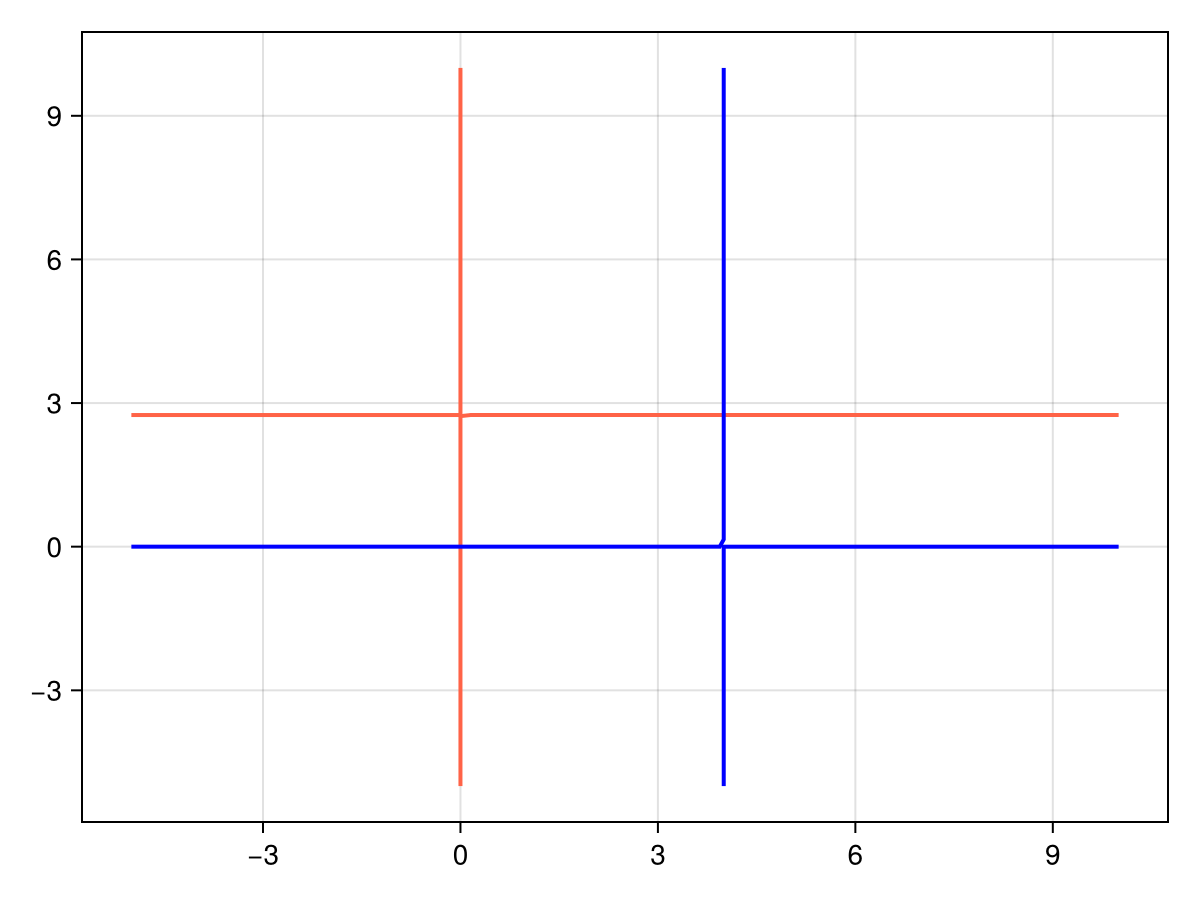

In [8]:
params = [1.1, 0.4, 0.4, 0.1]
fig = Figure(figsize=(500,500))
ax = Axis(fig[1,1])

draw_nullcline!(ax, prey_predator!, 1, params, :tomato, 2)
draw_nullcline!(ax, prey_predator!, 2, params, :blue, 2)

fig

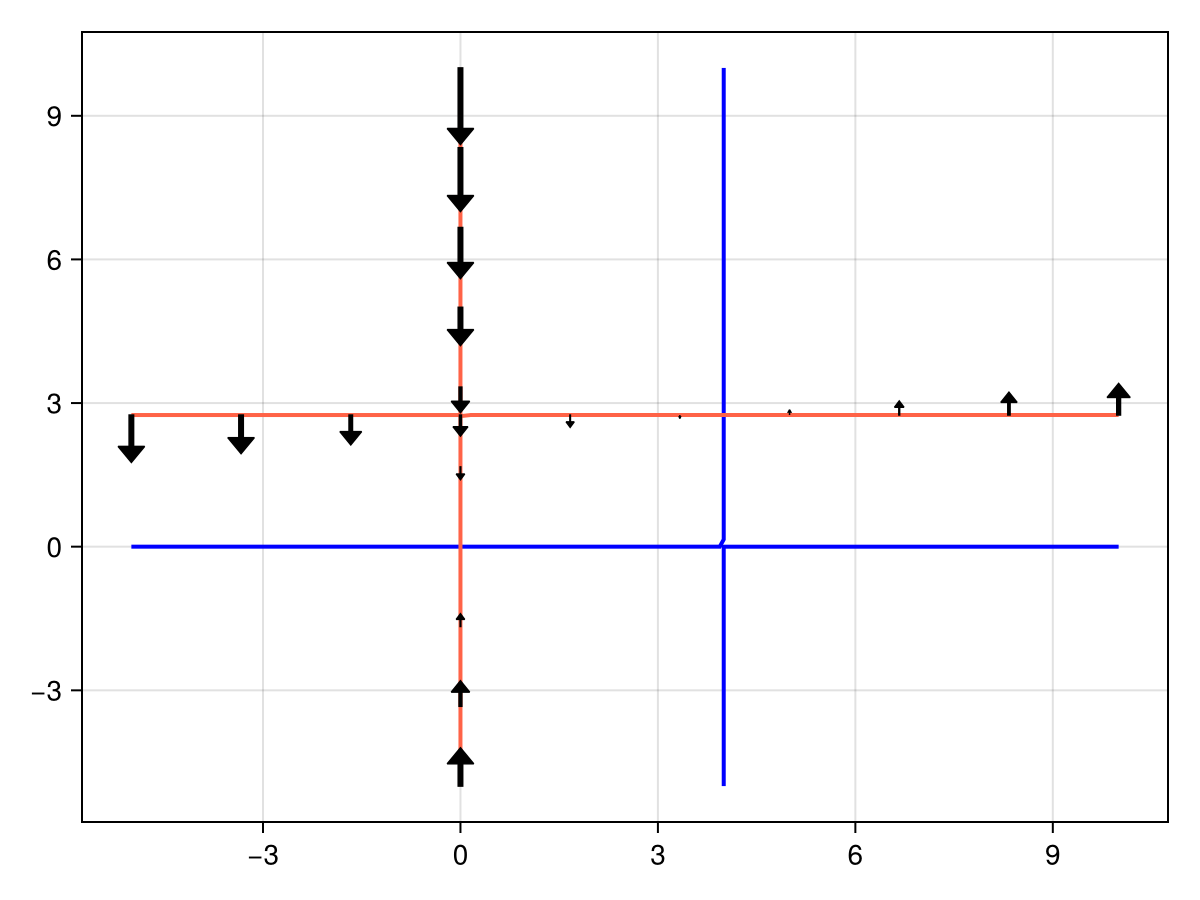

In [9]:
params = [1.1, 0.4, 0.4, 0.1]
fig = Figure(figsize=(500,500))
ax = Axis(fig[1,1])

# draw_nullcline!(ax, prey_predator!, 1, params, :tomato, 2)
draw_nullcline!(ax, prey_predator!, 2, params, :blue, 2)
draw_arrows_on_nullcline!(ax, prey_predator!, 1, params, :tomato, 2, 0.4)
# draw_arrows_on_nullcline!(ax, prey_predator!, 2, params, :blue, 2, 0.4)

fig

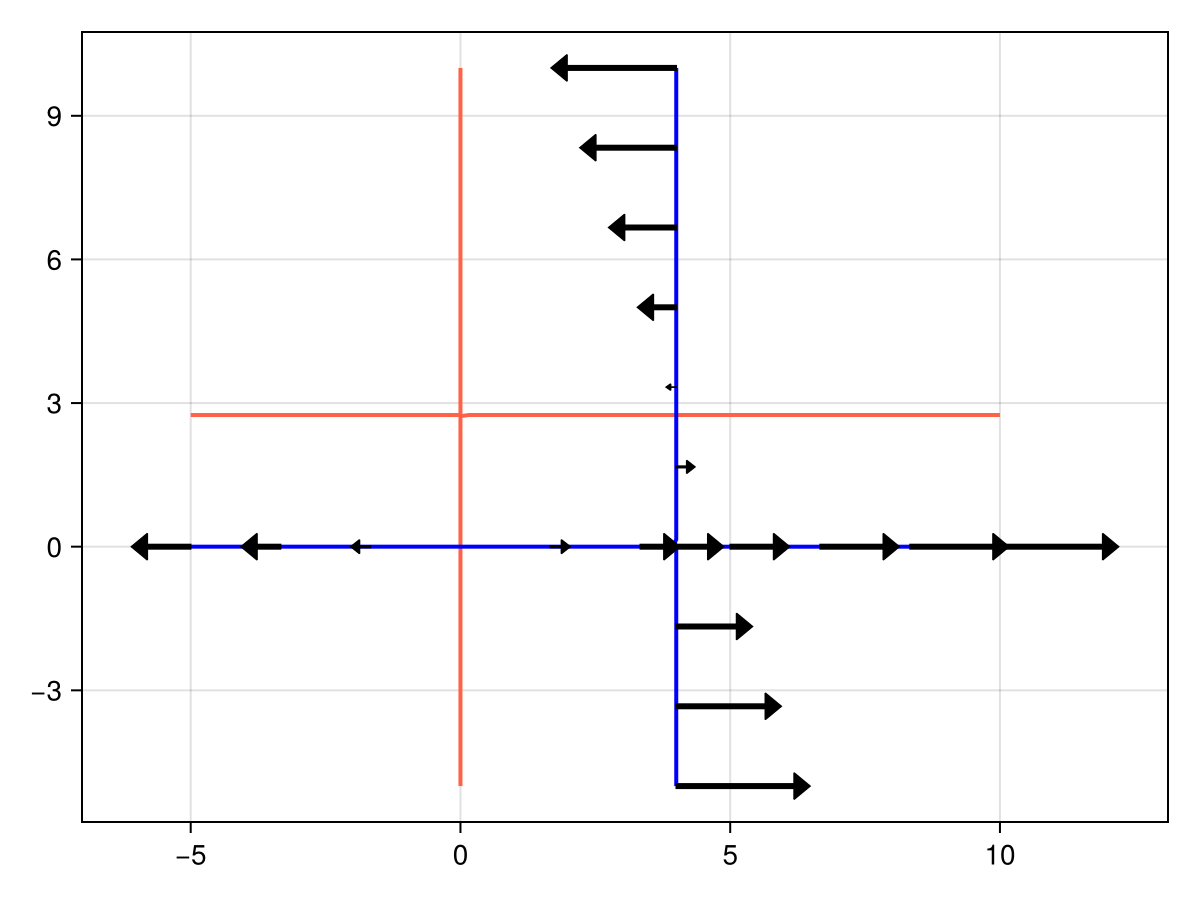

In [10]:
params = [1.1, 0.4, 0.4, 0.1]
fig = Figure(figsize=(500,500))
ax = Axis(fig[1,1])

draw_nullcline!(ax, prey_predator!, 1, params, :tomato, 2)
# draw_nullcline!(ax, prey_predator!, 2, params, :blue, 2)
# draw_arrows_on_nullcline!(ax, prey_predator!, 1, params, :tomato, 2, 0.4)
draw_arrows_on_nullcline!(ax, prey_predator!, 2, params, :blue, 2, 0.2)

fig

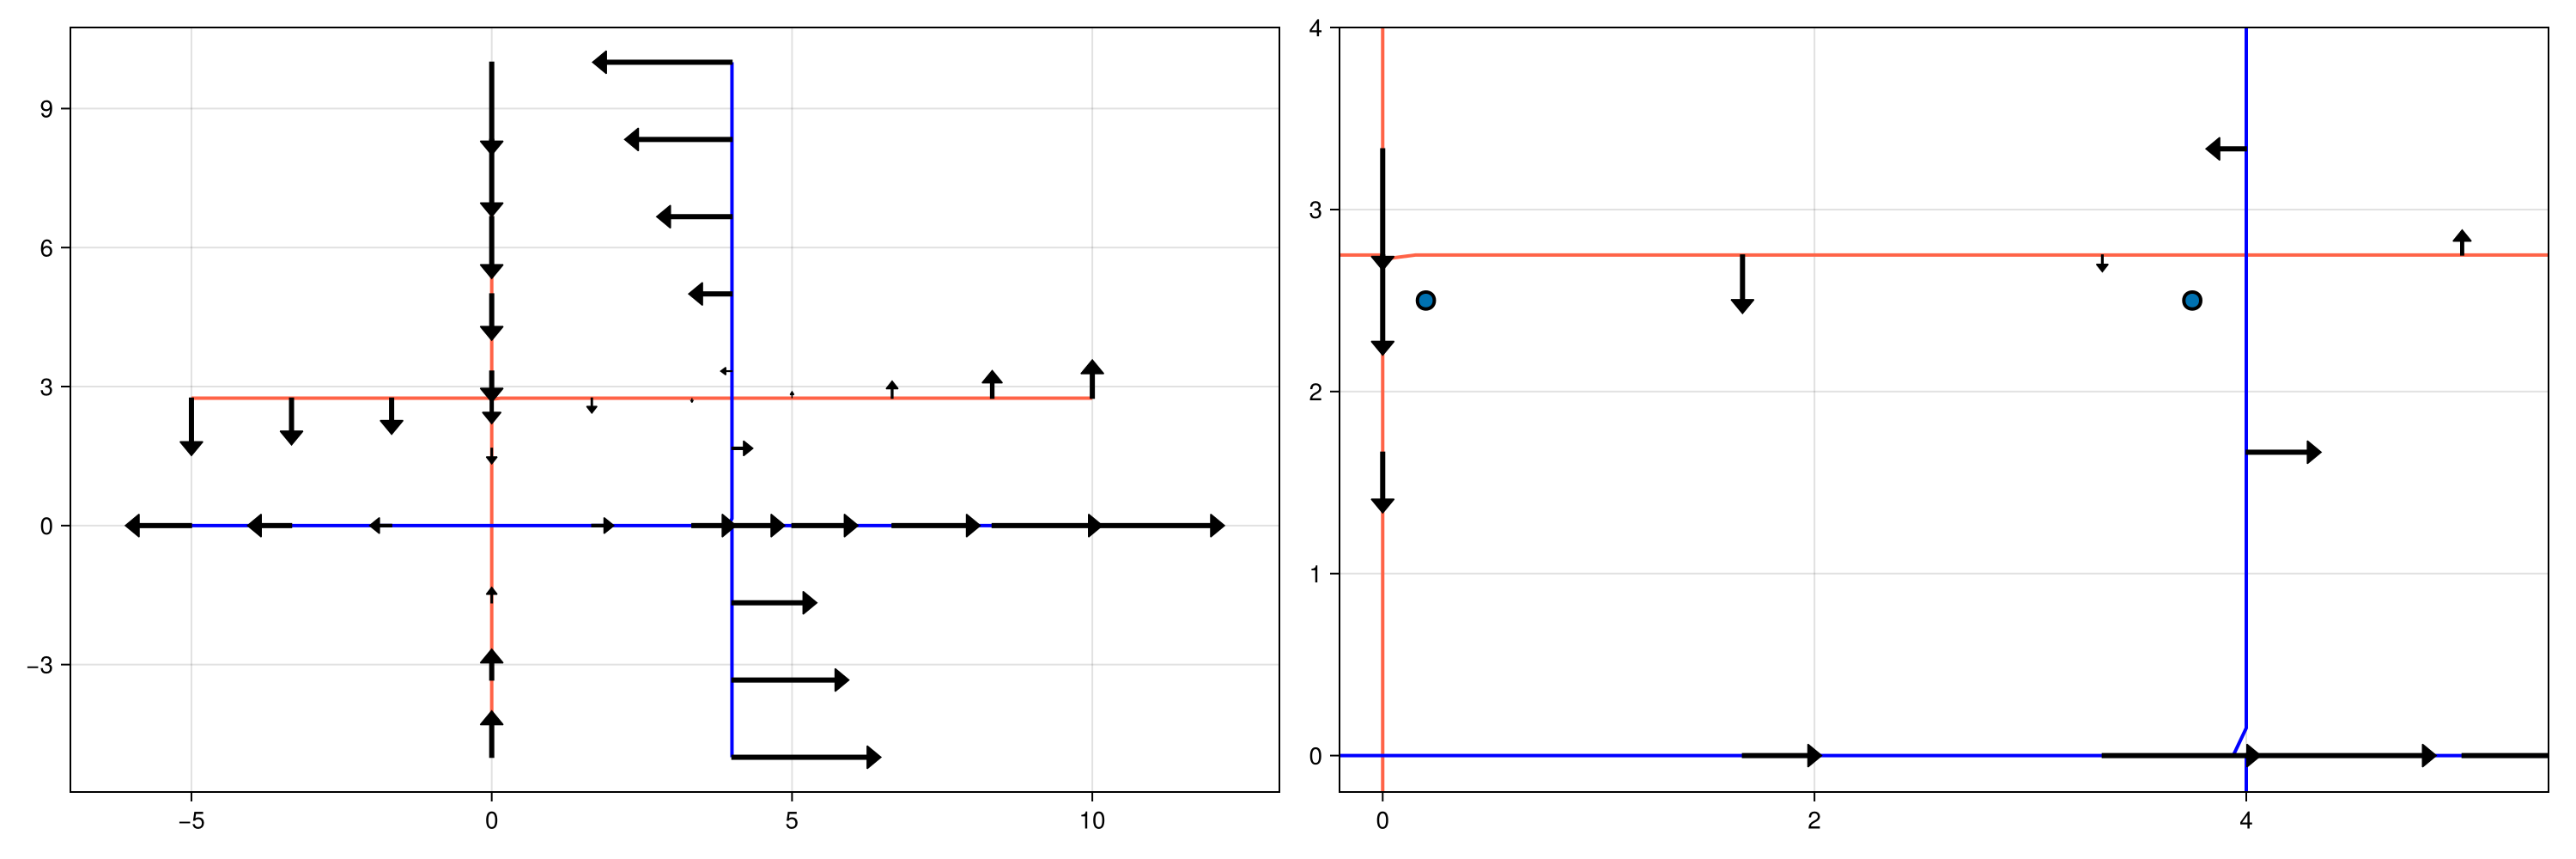

In [11]:
params = [1.1, 0.4, 0.4, 0.1]
fig = Figure(size=(1500,500))
ga = fig[1,1] = GridLayout()
gb = fig[1,2] = GridLayout()
ax1 = Axis(ga[1,1])
ax2 = Axis(gb[1,1])

# draw_nullcline!(ax, prey_predator!, 1, params, :tomato, 2)
# draw_nullcline!(ax, prey_predator!, 2, params, :blue, 2)
draw_arrows_on_nullcline!(ax1, prey_predator!, 1, params, :tomato, 2, 0.5)
draw_arrows_on_nullcline!(ax1, prey_predator!, 2, params, :blue, 2, 0.2)


draw_arrows_on_nullcline!(ax2, prey_predator!, 1, params, :tomato, 2, 0.5)
draw_arrows_on_nullcline!(ax2, prey_predator!, 2, params, :blue, 2, 0.2)

init1 = [0.2, 2.5]
init2 = [3.75, 2.5]

scatter!(ax2, [init1[1],init2[1]],[init1[2], init2[2]], markersize=14, strokewidth=2)
xlims!(ax2, -0.2,5.4)
ylims!(ax2, -0.2,4)
fig

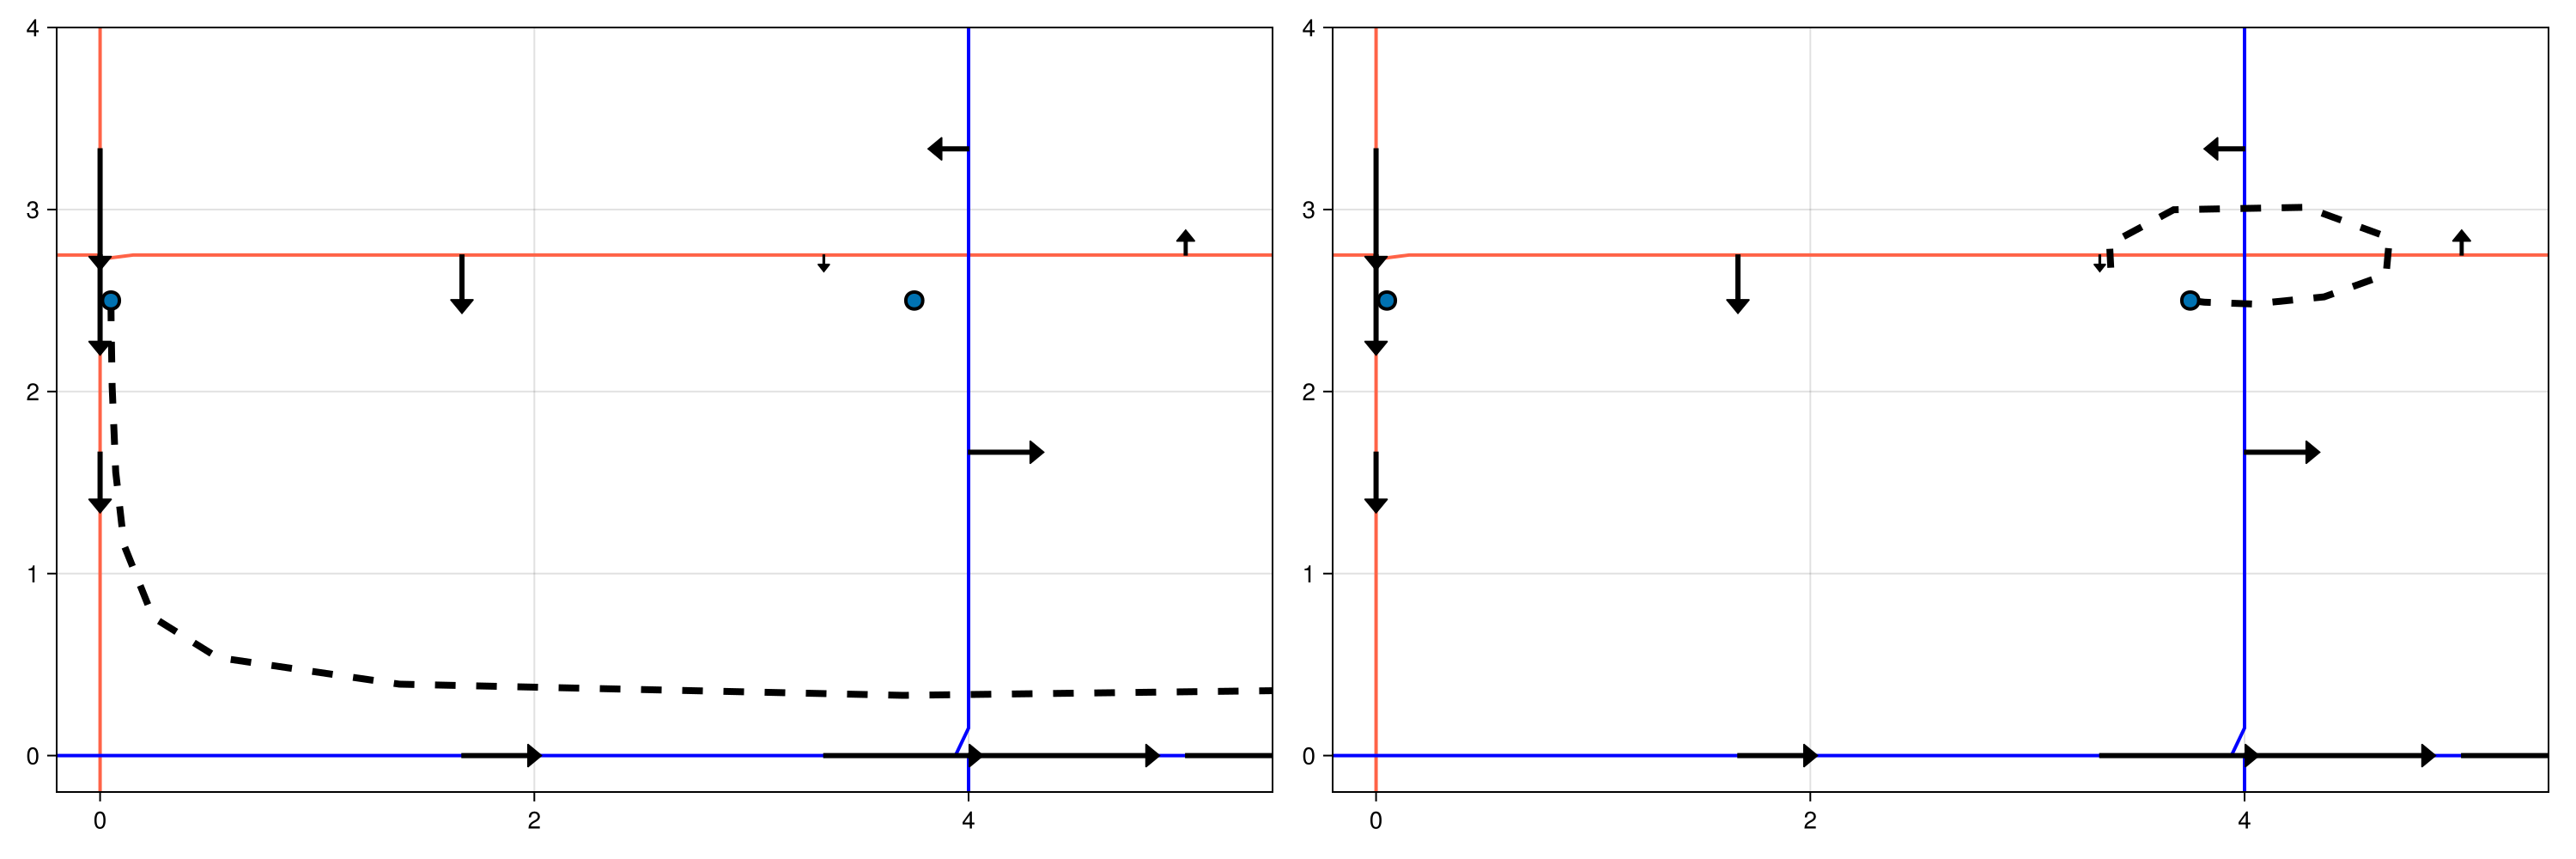

In [12]:
params = [1.1, 0.4, 0.4, 0.1]
fig = Figure(size=(1500,500))
ga = fig[1,1] = GridLayout()
gb = fig[1,2] = GridLayout()
ax1 = Axis(ga[1,1])
ax2 = Axis(gb[1,1])

# draw_nullcline!(ax, prey_predator!, 1, params, :tomato, 2)
# draw_nullcline!(ax, prey_predator!, 2, params, :blue, 2)
draw_arrows_on_nullcline!(ax1, prey_predator!, 1, params, :tomato, 2, 0.5)
draw_arrows_on_nullcline!(ax1, prey_predator!, 2, params, :blue, 2, 0.2)


draw_arrows_on_nullcline!(ax2, prey_predator!, 1, params, :tomato, 2, 0.5)
draw_arrows_on_nullcline!(ax2, prey_predator!, 2, params, :blue, 2, 0.2)

init1 = [0.05, 2.5]
init2 = [3.75, 2.5]

l_axs = [ax1, ax2]
l_inits = [init1, init2]
tspan = (0.0,8)

for (ax,init) in zip(l_axs, l_inits)
    prob = ODEProblem(prey_predator!, init, tspan, params)
    sol = solve(prob)
    lines!(ax, sol[1,:], sol[2,:], color=:black, linestyle=:dash, linewidth=4)
end

scatter!(ax1, [init1[1],init2[1]],[init1[2], init2[2]], markersize=14, strokewidth=2)
scatter!(ax2, [init1[1],init2[1]],[init1[2], init2[2]], markersize=14, strokewidth=2)
xlims!(ax1, -0.2,5.4)
ylims!(ax1, -0.2,4)
xlims!(ax2, -0.2,5.4)
ylims!(ax2, -0.2,4)

fig

In [13]:
@syms R F α β γ δ

dR = α*R - β*R*F
dF = δ*R*F - γ*F
[dR ; dF]

2-element Vector{Sym{PyCall.PyObject}}:
 -F⋅R⋅β + R⋅α
  F⋅R⋅δ - F⋅γ

In [14]:
dNs = [dR, dF]
Ns = [R, F]

2-element Vector{Sym{PyCall.PyObject}}:
 R
 F

In [15]:
equilibria = solve(dNs, Ns)

2-element Vector{Tuple{Sym{PyCall.PyObject}, Sym{PyCall.PyObject}}}:
 (0, 0)
 (γ/δ, α/β)

In [16]:
Jac = Matrix([
    diff(dR, R)  diff(dR, F);
    diff(dF, R)  diff(dF, F)
])

2×2 Matrix{Sym{PyCall.PyObject}}:
 -F⋅β + α     -R⋅β
      F⋅δ  R⋅δ - γ

In [17]:
l_jeval = []
for eq in equilibria
    println("Equilibrium: ", eq)
    sub_dict = Dict(R => eq[1], F => eq[2])
    J_eval = Jac.subs(sub_dict)
    push!(l_jeval, J_eval)
end

Equilibrium: (0, 0)
Equilibrium: (γ/δ, α/β)


In [18]:
l_jeval[1]

2×2 Matrix{Sym{PyCall.PyObject}}:
 α   0
 0  -γ

In [19]:
l_jeval[2]

2×2 Matrix{Sym{PyCall.PyObject}}:
     0  -β*γ/δ
 α*δ/β       0

In [20]:
function plot_eigs!(ax, param_dict, eq_number)

    jac_eval = l_jeval[eq_number].subs(param_dict)
    eigs = eigen(jac_eval).values

    scatter!(ax, Float64(real(eigs[1])), Float64(imag(eigs[1])), markersize=10, strokewidth=2 )
    scatter!(ax, Float64(real(eigs[2])), Float64(imag(eigs[2])), markersize=10, strokewidth=2 )

end

plot_eigs! (generic function with 1 method)

In [21]:
# img = load("/home/arun/Downloads/monaLisa.jpg") 
# img = imresize(img, ratio=1/10)
# save("/home/arun/Downloads/monaLisa.jpg", img)

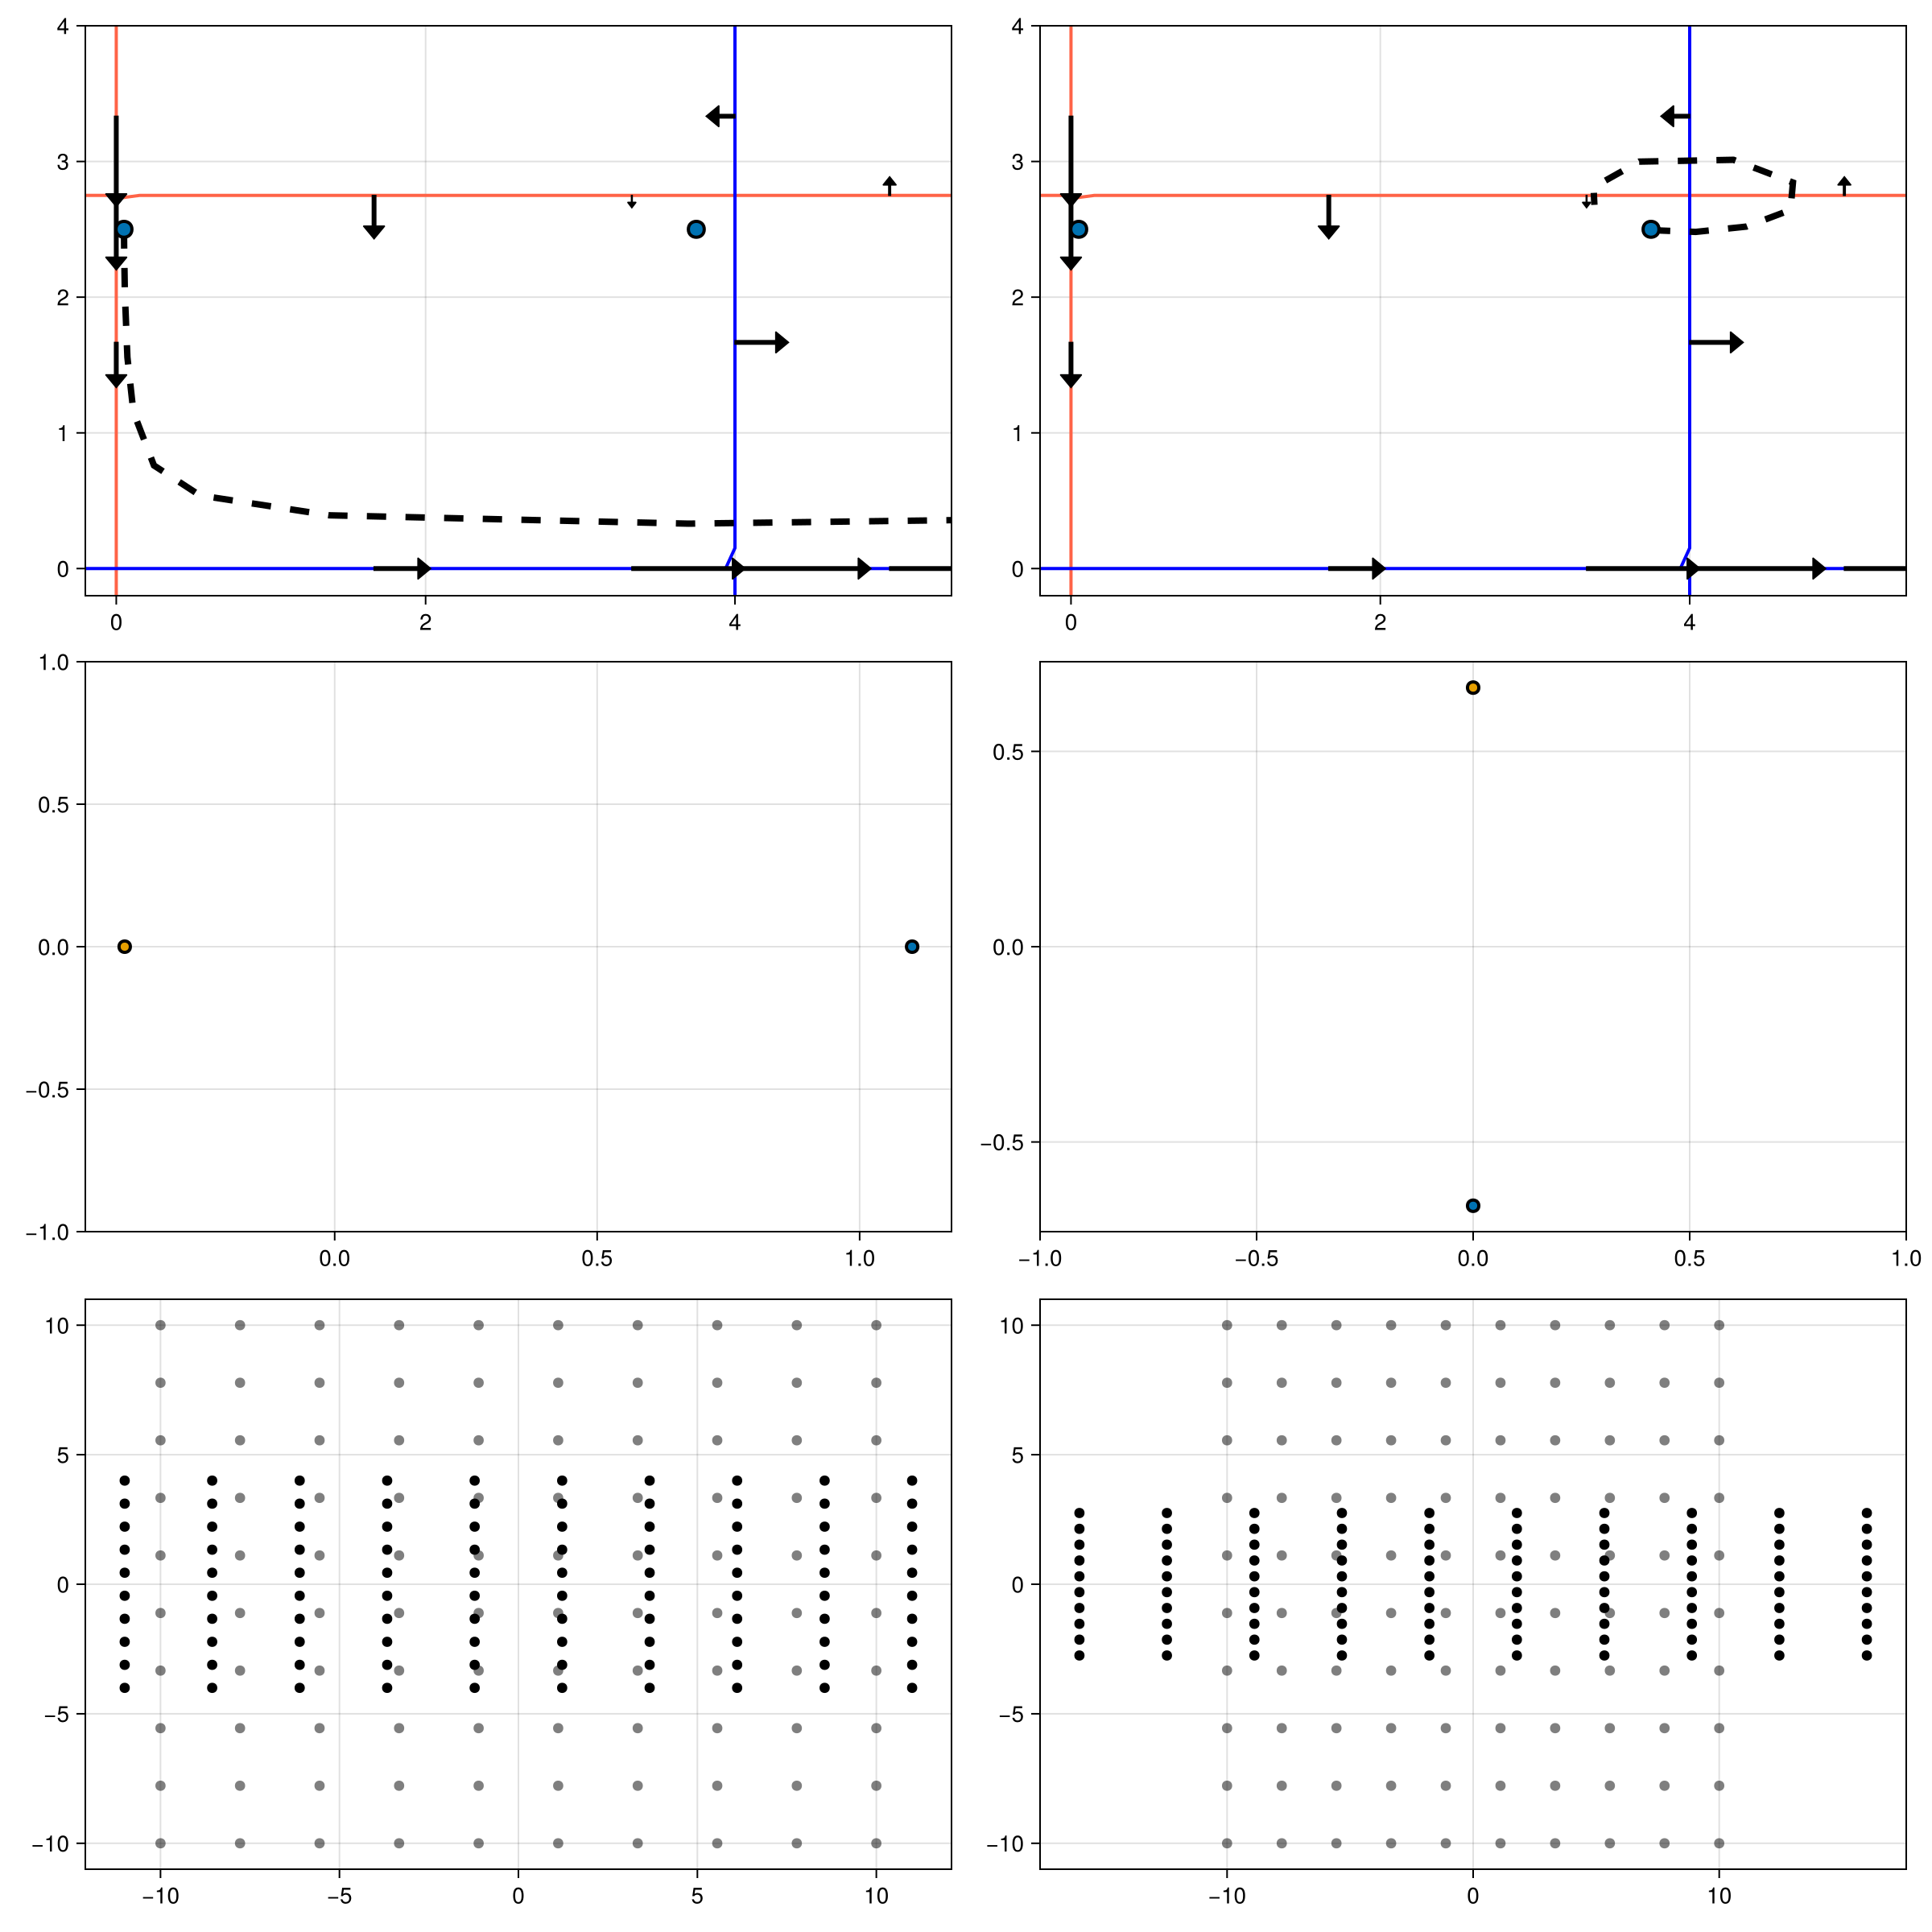

In [22]:

fig = Figure(size=(1200,1200))
ga = fig[1,1] = GridLayout()
gb = fig[2,1] = GridLayout()
gc = fig[3,1] = GridLayout()


gd = fig[1,2] = GridLayout()
ge = fig[2,2] = GridLayout()
gf = fig[3,2] = GridLayout()


ax1 = Axis(ga[1,1]) 
ax2 = Axis(gb[1,1])
ax3 = Axis(gc[1,1])
ax4 = Axis(gd[1,1])
ax5 = Axis(ge[1,1])
ax6 = Axis(gf[1,1])


param_dict = Dict(α => params[1] , β => params[2], γ => params[3], δ => params[4])
plot_eigs!(ax2, param_dict, 1)
plot_eigs!(ax5, param_dict, 2)


draw_arrows_on_nullcline!(ax1, prey_predator!, 1, params, :tomato, 2, 0.5)
draw_arrows_on_nullcline!(ax1, prey_predator!, 2, params, :blue, 2, 0.2)


draw_arrows_on_nullcline!(ax4, prey_predator!, 1, params, :tomato, 2, 0.5)
draw_arrows_on_nullcline!(ax4, prey_predator!, 2, params, :blue, 2, 0.2)

init1 = [0.05, 2.5]
init2 = [3.75, 2.5]

l_axs = [ax1, ax4]
l_inits = [init1, init2]
tspan = (0.0,8)

for (ax,init) in zip(l_axs, l_inits)
    prob = ODEProblem(prey_predator!, init, tspan, params)
    sol = solve(prob)
    lines!(ax, sol[1,:], sol[2,:], color=:black, linestyle=:dash, linewidth=4)
end

scatter!(ax1, [init1[1],init2[1]],[init1[2], init2[2]], markersize=14, strokewidth=2)
scatter!(ax4, [init1[1],init2[1]],[init1[2], init2[2]], markersize=14, strokewidth=2)
xlims!(ax1, -0.2,5.4)
ylims!(ax1, -0.2,4)
xlims!(ax4, -0.2,5.4)
ylims!(ax4, -0.2,4)

Jac1 = Float64.(l_jeval[1].subs(param_dict))
Jac2 = Float64.(l_jeval[2].subs(param_dict))

range_points = LinRange(-10,10,10)
lattice_points = [[x,y] for x in  range_points for y in range_points]
lattice = hcat(lattice_points...)
lattice_transformed_1 = Jac1 * lattice
scatter!(ax3, lattice_transformed_1[1,:], lattice_transformed_1[2,:], color=:black)
scatter!(ax3, lattice[1,:], lattice[2,:], color=:black, alpha=0.5)

range_points = LinRange(-10,10,10)
lattice_points = [[x,y] for x in  range_points for y in range_points]
lattice = hcat(lattice_points...)
lattice_transformed_2 = Jac2 * lattice
scatter!(ax6, lattice_transformed_2[1,:], lattice_transformed_2[2,:], color=:black)
scatter!(ax6, lattice[1,:], lattice[2,:], color=:black, alpha=0.5)


fig

In [23]:
jac_eval = l_jeval[2].subs(param_dict)

2×2 Matrix{Sym{PyCall.PyObject}}:
                 0  -1.60000000000000
 0.275000000000000                  0

In [24]:
eigs = eigen(jac_eval).values

2-element Vector{Sym{PyCall.PyObject}}:
 -0.66332495807108⋅ⅈ
  0.66332495807108⋅ⅈ

In [25]:
Float64(imag(eigs[1]))

-0.66332495807108

In [26]:
?Point2f

search: Point2f Point2d Point2 Point2i Point3f Point4f Point4i Point3i Point



```julia
Point{N, T}(args...)
Point{N, T}(args::Union{AbstractVector, Tuple, NTuple, StaticVector})
```

Constructs a Point of length `N` from the given arguments.

Note that Point and Vec don't follow strict mathematical definitions. Instead we allow them to be used interchangeably.

## Aliases

|     |          `T` |   `Float64` |   `Float32` |       `Int` |       `UInt` |
| ---:| ------------:| -----------:| -----------:| -----------:| ------------:|
| `N` | `Point{N,T}` | `Pointd{N}` | `Pointf{N}` | `Pointi{N}` | `Pointui{N}` |
| `2` |  `Point2{T}` |   `Point2d` |   `Point2f` |   `Point2i` |   `Point2ui` |
| `3` |  `Point3{T}` |   `Point3d` |   `Point3f` |   `Point3i` |   `Point3ui` |
